# DistilBERT for Sentiment Analysis

In [1]:
!pip install -r requirements.txt

In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)
from transformers.utils.notebook import NotebookProgressCallback
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import evaluate
import wandb
import os
import torch
import gc
from config import SEED, NUM_LABELS, REPORT_TO
from config import WANDB_PROJECT 
from data_pipeline import set_seed, load_and_split, prepare_transformer_dataset

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# wandb login
wandb.login()
os.environ["WANDB_PROJECT"] = "D7047E-Lab1"
os.environ["WANDB_NAME"] = "distilbert-1K-run"
os.environ["WANDB_DISABLED"] = "false"

gc.collect()
torch.cuda.empty_cache()

In [4]:
set_seed(SEED)
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# 1. Loading 1k Data
print("Loading 1K Baseline Data")
splits = load_and_split(filepath="data/amazon_cells_labelled.txt")

print("Tokenizing the data")
train_ds = prepare_transformer_dataset(splits["train"]["texts"], splits["train"]["labels"], MODEL_NAME)
val_ds = prepare_transformer_dataset(splits["val"]["texts"], splits["val"]["labels"], MODEL_NAME)
test_ds = prepare_transformer_dataset(splits["test"]["texts"], splits["test"]["labels"], MODEL_NAME)
# 2. Loading DistilBERT Model
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

# 3. Setup Metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average="binary"
    )
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

batch_size = 16
# 4. Training Arguments
args = TrainingArguments(
    output_dir="./results/distilbert_1k_baseline",
    num_train_epochs=10,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size * 2,
    learning_rate=2e-5,
    weight_decay=0.01,
    fp16=True,                               
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_steps=50,
    report_to="wandb",                        
    run_name="distilbert_1k",
    seed=SEED, 
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# 5. Initialize and Train
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds, 
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("Starting DistilBERT 1K Baseline Training")
start_time = time.time()
trainer.train()
try:
    trainer.remove_callback(NotebookProgressCallback)
except ValueError:
    pass
print(f"Training completed in {time.time() - start_time:.1f}s")

# 6. Final Results
test_output = trainer.predict(test_ds)
print("\n==============================================")
print(f"  DistilBERT 1K TEST Accuracy:  {test_output.metrics['test_accuracy'] * 100:.2f}%")
print(f"  DistilBERT 1K TEST Precision: {test_output.metrics['test_precision'] * 100:.2f}%")
print(f"  DistilBERT 1K TEST Recall:    {test_output.metrics['test_recall'] * 100:.2f}%")
print(f"  DistilBERT 1K TEST F1-Score:  {test_output.metrics['test_f1'] * 100:.2f}%")
print("==============================================")

Loading 1K Baseline Data
Tokenizing the data


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 9213.80it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting DistilBERT 1K Baseline Training


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.561779,0.252505,0.930000,0.957447,0.900000,0.927835
2,0.175670,0.217200,0.920000,0.920000,0.920000,0.920000
3,0.077199,0.252504,0.910000,0.918367,0.900000,0.909091
4,0.039813,0.342766,0.920000,0.937500,0.900000,0.918367


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.02it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Training completed in 15.8s

  DistilBERT 1K TEST Accuracy:  91.00%
  DistilBERT 1K TEST Precision: 90.20%
  DistilBERT 1K TEST Recall:    92.00%
  DistilBERT 1K TEST F1-Score:  91.09%


Fetching Test Accuracy


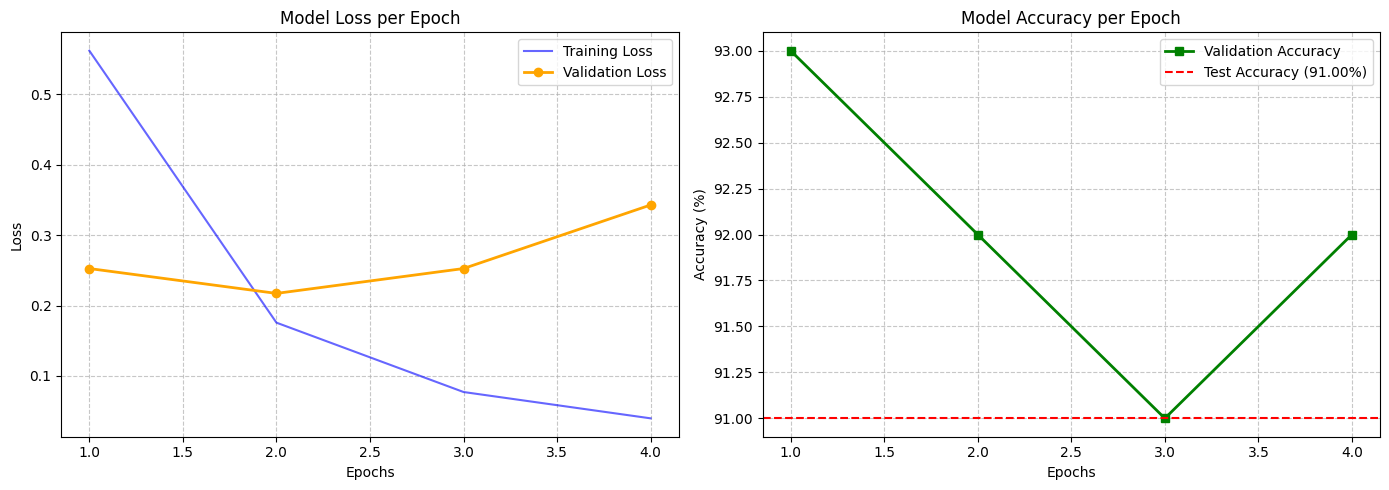

Plots saved successfully to ./results/distilbert_training_curves.png


eval/accuracy,█▅▁▅
eval/f1,█▅▁▄
eval/loss,▃▁▃█
eval/precision,█▁▁▄
eval/recall,▁█▁▁
eval/runtime,█▁▂▁
eval/samples_per_second,▁█▇█
eval/steps_per_second,▁█▇█
test/accuracy,▁▁
test/f1,▁▁
+11,...


In [5]:
log_history = trainer.state.log_history

# Initializing lists
train_epochs, train_loss = [], []
val_epochs, val_loss, val_acc = [], [], []

for log in log_history:
    if 'loss' in log and 'epoch' in log:
        train_loss.append(log['loss'])
        train_epochs.append(log['epoch'])
    elif 'eval_loss' in log and 'epoch' in log:
        val_loss.append(log['eval_loss'])
        val_epochs.append(log['epoch'])   
        if 'eval_accuracy' in log:
            val_acc.append(log['eval_accuracy'])

# Test Accuracy 
print("Fetching Test Accuracy")
test_output = trainer.predict(test_ds)
test_results = test_output.metrics

test_acc = test_results.get('test_accuracy', 0)

# Creating the Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Model Loss ---
ax1.plot(train_epochs, train_loss, label='Training Loss', color='blue', alpha=0.6)
ax1.plot(val_epochs, val_loss, label='Validation Loss', color='orange', marker='o', linewidth=2)

ax1.set_title('Model Loss per Epoch')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# --- Plot 2: Model Accuracy ---
ax2.plot(val_epochs, [acc * 100 for acc in val_acc], label='Validation Accuracy', color='green', marker='s', linewidth=2)

if test_acc > 0:
    ax2.axhline(y=test_acc * 100, color='red', linestyle='--', label=f'Test Accuracy ({test_acc * 100:.2f}%)')

ax2.set_title('Model Accuracy per Epoch')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

# Save and Show
os.makedirs('./results', exist_ok=True)
plt.tight_layout()
plt.savefig('./results/distilbert_training_curves.png', dpi=300)
plt.show()

print("Plots saved successfully to ./results/distilbert_training_curves.png")

# Close wandb
wandb.finish()